# Supervised Learning - Logistic Regression Hands-on Exercise

## Getting the Data

We are using a dataset from the UCI Machine Learning Repository.

Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

You can download the data from the UCI website: <https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients>

Here we are going to retrieve the data from the UCI website using the `ucimlrepo` library.

In [2]:
!pip install -q ucimlrepo

In [1]:
# The UCI Machine Learning Repository provides a Package for accessing
# the data sets.

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
default_of_credit_card_clients = fetch_ucirepo(id=350) 
  
# data (as pandas dataframes) 
X_orig = default_of_credit_card_clients.data.features 
y_orig = default_of_credit_card_clients.data.targets 

# metadata 
print(default_of_credit_card_clients.metadata) 
  
# variable information 
print(default_of_credit_card_clients.variables) 

{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

In [2]:
# We will be using Pandas for data manipulation.
import pandas as pd

In [3]:
# Some basic data exploration.
X_orig.info()
X_orig.describe()
X_orig.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
dtypes: int64(23

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [5]:
# Let's see what feature columns we have in the dataset.
default_of_credit_card_clients.variables['description']

0                           None
1                      LIMIT_BAL
2                            SEX
3                      EDUCATION
4                       MARRIAGE
5                            AGE
6                          PAY_0
7                          PAY_2
8                          PAY_3
9                          PAY_4
10                         PAY_5
11                         PAY_6
12                     BILL_AMT1
13                     BILL_AMT2
14                     BILL_AMT3
15                     BILL_AMT4
16                     BILL_AMT5
17                     BILL_AMT6
18                      PAY_AMT1
19                      PAY_AMT2
20                      PAY_AMT3
21                      PAY_AMT4
22                      PAY_AMT5
23                      PAY_AMT6
24    default payment next month
Name: description, dtype: object

In [6]:
# Keep a copy of the original data we can use later.
X = X_orig.copy()
y = y_orig.copy()['Y']

# Rename the columns to be more descriptive.
# Drop the first variable (index), and the last column (label) to match the dataframe.
default_of_credit_card_clients.variables['description'][1:-1]
X.columns = default_of_credit_card_clients.variables['description'][1:-1]
X.head()

description,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [7]:
# Install additional packages.
# We are using matplotlib and seaborn for plotting and numpy for numerical operations.
!pip install -q matplotlib seaborn numpy
# We are using scikit-learn for logistic regression model and data utils.
!pip install -q scikit-learn

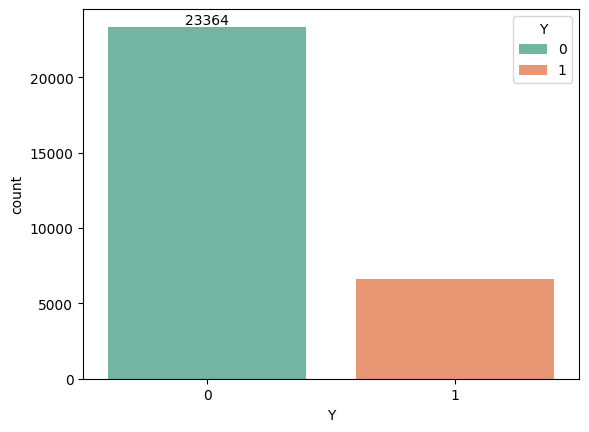

In [8]:
from matplotlib import pyplot as plt
import seaborn as sns

# Let's look at whether the classes label are balanced.
ax = sns.countplot(data=y_orig, x='Y', hue='Y', palette='Set2')
ax.bar_label(ax.containers[0])
plt.show()

Looks like we have a lot fewer defaults than the non-defaulted loans.

This makes sense, but imbalanced data can be a problem for some models.

In [9]:
# Inspect columns for missing data.
cols_na = [col for col in X.columns if X[col].isnull().sum() > 1]

for col in cols_na:
    print(f"{col}, {round(X[col].isnull().mean(), 4)} % Missing values")

In [10]:
# Look at rows with missing values
missing_indexes = X.isnull().any(axis=1)
if missing_indexes.any():
    print('Rows with missing values:')
    X[missing_indexes]
else:
    print('No rows with missing values')

No rows with missing values


In [11]:
# Now we are ready to import the data and split it into training and test sets.
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=781)

In [12]:
from sklearn import preprocessing

# Preprocess the data to Z-score it.
# This is a common preprocessing step to make sure all the features are on the same scale.

# We will use the same scaler to transform the test data.
scaler = preprocessing.StandardScaler().fit(X_train)

X_scaled = scaler.transform(X_train)

In [13]:
# Create the model.

# This model class supports many additional parameters.
# See the documentation for more information.

lr_model = LogisticRegression(verbose=True, max_iter=1000)

# Note that the default solver is 'lbfgs'.
# This solver is generally the best choice for smaller datasets.
# For larger datasets, 'sag' and 'saga' solvers are faster.
# You can find more information about these solvers at
# https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

# You can also use stochastic gradient descent (SGD) to train the model.

# Fit the model to the scaled train data split.
_ = lr_model.fit(X_scaled, y_train)

In [14]:
# Use score method to get accuracy of model after scaling the test data.
X_test_scaled = scaler.transform(X_test)

score = lr_model.score(X_test_scaled, y_test)
print(f"Accuracy={score}")

Accuracy=0.8045


In [15]:
# Get predictions for the test model to evaluate metrics.
y_pred = lr_model.predict(X_test_scaled)

In [18]:
from sklearn import metrics
cr = metrics.classification_report(y_test, y_pred, target_names=['nodefault', 'nodefault'])

# The classification report is a summary of the precision, recall, F1 score for each class.
print(cr)

              precision    recall  f1-score   support

   nodefault       0.81      0.97      0.89      4673
   nodefault       0.68      0.22      0.33      1327

    accuracy                           0.80      6000
   macro avg       0.75      0.59      0.61      6000
weighted avg       0.78      0.80      0.76      6000



In [19]:
# A confusion matrix is a more visual, intuitive way to understand the performance of a classification model across classes.

def plot_confusion_matrix(cm):
    # Plot the correlation matrix with Seaborn.
    sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
    plt.ylabel('Actual');
    plt.xlabel('Predicted');
    plt.title('Confusion Matrix', size = 15);

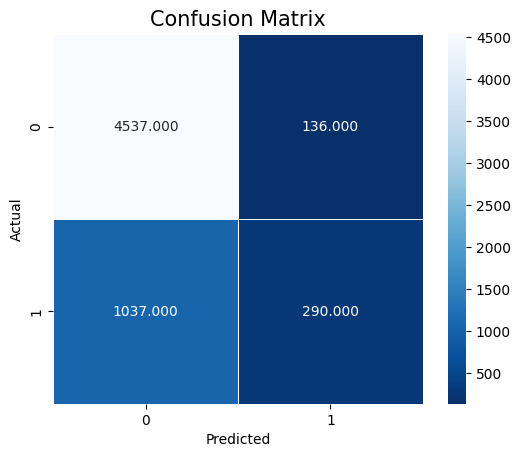

In [20]:
cm = metrics.confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm)

## Bonus - SGD Version using sklearn Pipeline

In [79]:
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# SGDClassifier is a linear classifier using Stochastic Gradient Descent (SGD) learning.

# Pipelines are convenient way to define a sequence of transformations.

# loss='log_loss' will implement logistic regression
# loss='hinge' will implement SVM
sgd_model = SGDClassifier(
    #loss='hinge', penalty="none",
    loss='log_loss', penalty="l2",
    max_iter=1000, early_stopping=True,
    validation_fraction=0.2, random_state=7834, tol=1e-3, verbose=1)

clf = make_pipeline(
    StandardScaler(),
    sgd_model)

In [84]:
# It takes some work to get the loss curve to show up in the notebook during training with scikit-learn.
# This is a workaround. See https://stackoverflow.com/questions/44443479/how-to-show-loss-values-during-training-in-scikit-learn

import sys
import io
import matplotlib.pyplot as plt

class DisplayLossCurve(object):
  """Make sure the model verbose is set to 1"""
  def __enter__(self):
    self.old_stdout = sys.stdout
    sys.stdout = self.mystdout = io.StringIO()
  
  def __exit__(self, *args, **kwargs):
    sys.stdout = self.old_stdout
    loss_history = self.mystdout.getvalue()
    loss_list = []
    for line in loss_history.split('\n'):
      if(len(line.split("loss: ")) == 1):
        continue
      loss_list.append(float(line.split("loss: ")[-1]))
    plt.figure()
    plt.plot(np.arange(len(loss_list)), loss_list)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
      
    return True


In [ ]:
# remember our data is in X_train, X_test, y_train, y_test 

with DisplayLossCurve():
  clf.fit(X_train, y_train)

TypeError: DisplayLossCurve() takes no arguments

In [83]:
acc_score = clf.score(X_test, y_test)
print(f"Accuracy: {acc_score}")

y_hat = clf.predict(X_test)

cr = classification_report(y_test, y_hat)
print(cr) 


Accuracy: 0.788
              precision    recall  f1-score   support

           0       0.80      0.97      0.88      4673
           1       0.57      0.16      0.26      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.56      0.57      6000
weighted avg       0.75      0.79      0.74      6000

